In [1]:
!pip install open_clip_torch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import open_clip
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print("GPUs available:", num_gpus)

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-5   # smaller for CLIP finetuning
NUM_CLASSES = 100
EPS = 1e-8

selected_classes = list(range(NUM_CLASSES))

GPUs available: 2


In [3]:
class CLIPImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model

    def forward(self, x):
        return self.clip.encode_image(x)

In [4]:
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)

model = model.to(device)

# ---------------- MULTI GPU SETUP ----------------
image_encoder = nn.Module()

class CLIPImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model

    def forward(self, x):
        return self.clip.encode_image(x)

image_encoder = CLIPImageEncoder(model).to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel on image encoder")
    image_encoder = nn.DataParallel(image_encoder)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Using DataParallel on image encoder


In [5]:
# transform_train = preprocess
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    preprocess
])
transform_test = preprocess

def filter_dataset(dataset, selected_classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, selected_classes)

    dataset.data = dataset.data[mask]
    dataset.targets = targets[mask].tolist()

    label_map = {cls: i for i, cls in enumerate(selected_classes)}
    dataset.targets = [label_map[t] for t in dataset.targets]

    return dataset

train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform_test
)

train_dataset = filter_dataset(train_dataset, selected_classes)
test_dataset = filter_dataset(test_dataset, selected_classes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [7]:
feature_dim = model.visual.output_dim
classifier = nn.Sequential(
    nn.Linear(feature_dim, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 100)
)

model = model.to(device)
classifier = classifier.to(device)

In [9]:
def get_classifier_weight(classifier):
    if isinstance(classifier, nn.DataParallel):
        return classifier.module[-1].weight
    else:
        return classifier[-1].weight

In [10]:
criterion = nn.CrossEntropyLoss()

# optimizer = optim.AdamW(
#     list(model.parameters()) + list(classifier.parameters()),
#     lr=LR
# )

optimizer = torch.optim.AdamW([
    {"params": model.parameters(), "lr": 1e-7},
    {"params": classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

In [11]:
def encode_text(model, text_tokens):
    if isinstance(model, nn.DataParallel):
        return model.module.encode_text(text_tokens)
    return model.encode_text(text_tokens)


In [12]:
# ===================== ZERO-SHOT EVALUATION =====================

# Get class names from CIFAR-100
class_names = train_dataset.classes

# Keep only selected classes
selected_class_names = [class_names[i] for i in selected_classes]

# Create prompts
prompts = [f"a photo of a {name}" for name in selected_class_names]

# Tokenize text
tokenizer = open_clip.get_tokenizer('ViT-B-32')
text_tokens = tokenizer(prompts).to(device)

# Encode text
with torch.no_grad():
    text_features = encode_text(model, text_tokens)

    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# -------- Evaluate --------
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Zero-shot Evaluation"):
        images, labels = images.to(device), labels.to(device)

        image_features = image_encoder(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Similarity
        logits = image_features @ text_features.T

        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------- Metrics --------
zero_shot_acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
zero_shot_f1_macro = f1_score(all_labels, all_preds, average='macro')
zero_shot_f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print("\n===== ZERO-SHOT RESULTS =====")
print(f"Accuracy: {zero_shot_acc:.2f}%")
print(f"F1 Macro: {zero_shot_f1_macro:.4f}")
print(f"F1 Weighted: {zero_shot_f1_weighted:.4f}")

Zero-shot Evaluation: 100%|██████████| 157/157 [00:25<00:00,  6.08it/s]


===== ZERO-SHOT RESULTS =====
Accuracy: 62.15%
F1 Macro: 0.6070
F1 Weighted: 0.6070


In [13]:
def compute_nc_metrics(features, labels, classifier_weights):
    features = features.cpu().numpy()
    labels = labels.cpu().numpy()
    W = classifier_weights.detach().cpu().numpy()

    K = len(np.unique(labels))

    class_means = []
    for k in range(K):
        class_k = features[labels == k]
        mu_k = np.mean(class_k, axis=0)
        class_means.append(mu_k)

    class_means = np.array(class_means)
    overall_mean = np.mean(features, axis=0)

    Sw = 0.0
    for k in range(K):
        class_k = features[labels == k]
        mu_k = class_means[k]
        Sw += np.sum((class_k - mu_k) ** 2)

    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    M = class_means - overall_mean
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)
    G = M @ M.T

    ETF = np.full((K, K), -1/(K-1))
    np.fill_diagonal(ETF, 1)

    nc2 = np.linalg.norm(G - ETF, ord='fro')

    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    nc3 = np.linalg.norm(W_norm - M, ord='fro')

    return nc1, nc2, nc3

In [14]:
def compute_relative_flatness(features, logits, labels, classifier_weights):
    probs = torch.softmax(logits, dim=1)
    idx = torch.arange(len(labels), device=labels.device)
    p_y = probs[idx, labels]

    curvature_term = p_y * (1 - p_y)
    feat_norm_sq = torch.sum(features**2, dim=1)

    trace_estimate = torch.mean(feat_norm_sq * curvature_term)

    weight_norm_sq = torch.sum(classifier_weights**2)

    return (trace_estimate / (weight_norm_sq + EPS)).item()

In [15]:
nc1_hist, nc2_hist, nc3_hist = [], [], []
flatness_hist = []

train_acc_hist, test_acc_hist = [], []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    classifier.train()

    train_preds, train_labels_all = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        features = image_encoder(images)
        features = features / features.norm(dim=-1, keepdim=True)
        outputs = classifier(features)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    train_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    train_acc_hist.append(train_acc)

    print(f"\nTrain Acc: {train_acc:.2f}%")

    # -------- TEST --------
    model.eval()
    classifier.eval()

    test_preds, test_labels_all = [], []

    all_features, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} [TEST]"):
            images, labels = images.to(device), labels.to(device)

            features = image_encoder(images)
            features = features / features.norm(dim=-1, keepdim=True)
            logits = classifier(features)

            preds = logits.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

            all_features.append(features)
            all_labels.append(labels)
            all_logits.append(logits)

    test_acc = np.mean(np.array(test_preds) == np.array(test_labels_all)) * 100
    test_acc_hist.append(test_acc)

    print(f"Test Acc: {test_acc:.2f}%")

    # -------- NC + FLATNESS --------
    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)
    all_logits = torch.cat(all_logits)

    nc1, nc2, nc3 = compute_nc_metrics(all_features, all_labels, get_classifier_weight(classifier))
    flatness = compute_relative_flatness(all_features, all_logits, all_labels, get_classifier_weight(classifier))

    nc1_hist.append(nc1)
    nc2_hist.append(nc2)
    nc3_hist.append(nc3)
    flatness_hist.append(flatness)

    print(f"NC1: {nc1:.6f} | NC2: {nc2:.6f} | NC3: {nc3:.6f}")
    print(f"Flatness: {flatness:.6f}")

Epoch 1 [TRAIN]: 100%|██████████| 782/782 [06:22<00:00,  2.05it/s]



Train Acc: 39.91%


Epoch 1 [TEST]: 100%|██████████| 157/157 [00:26<00:00,  5.91it/s]


Test Acc: 68.19%
NC1: 136.143646 | NC2: 24.426167 | NC3: 14.110108
Flatness: 0.000871


Epoch 2 [TRAIN]: 100%|██████████| 782/782 [06:27<00:00,  2.02it/s]


...

Test Acc: 84.27%
NC1: 122.511681 | NC2: 20.704790 | NC3: 14.116182
Flatness: 0.000041


Epoch 25 [TRAIN]: 100%|██████████| 782/782 [06:31<00:00,  2.00it/s]



Train Acc: 83.73%


Epoch 25 [TEST]: 100%|██████████| 157/157 [00:26<00:00,  5.87it/s]


Test Acc: 85.21%
NC1: 122.251099 | NC2: 20.670376 | NC3: 14.121495
Flatness: 0.000037


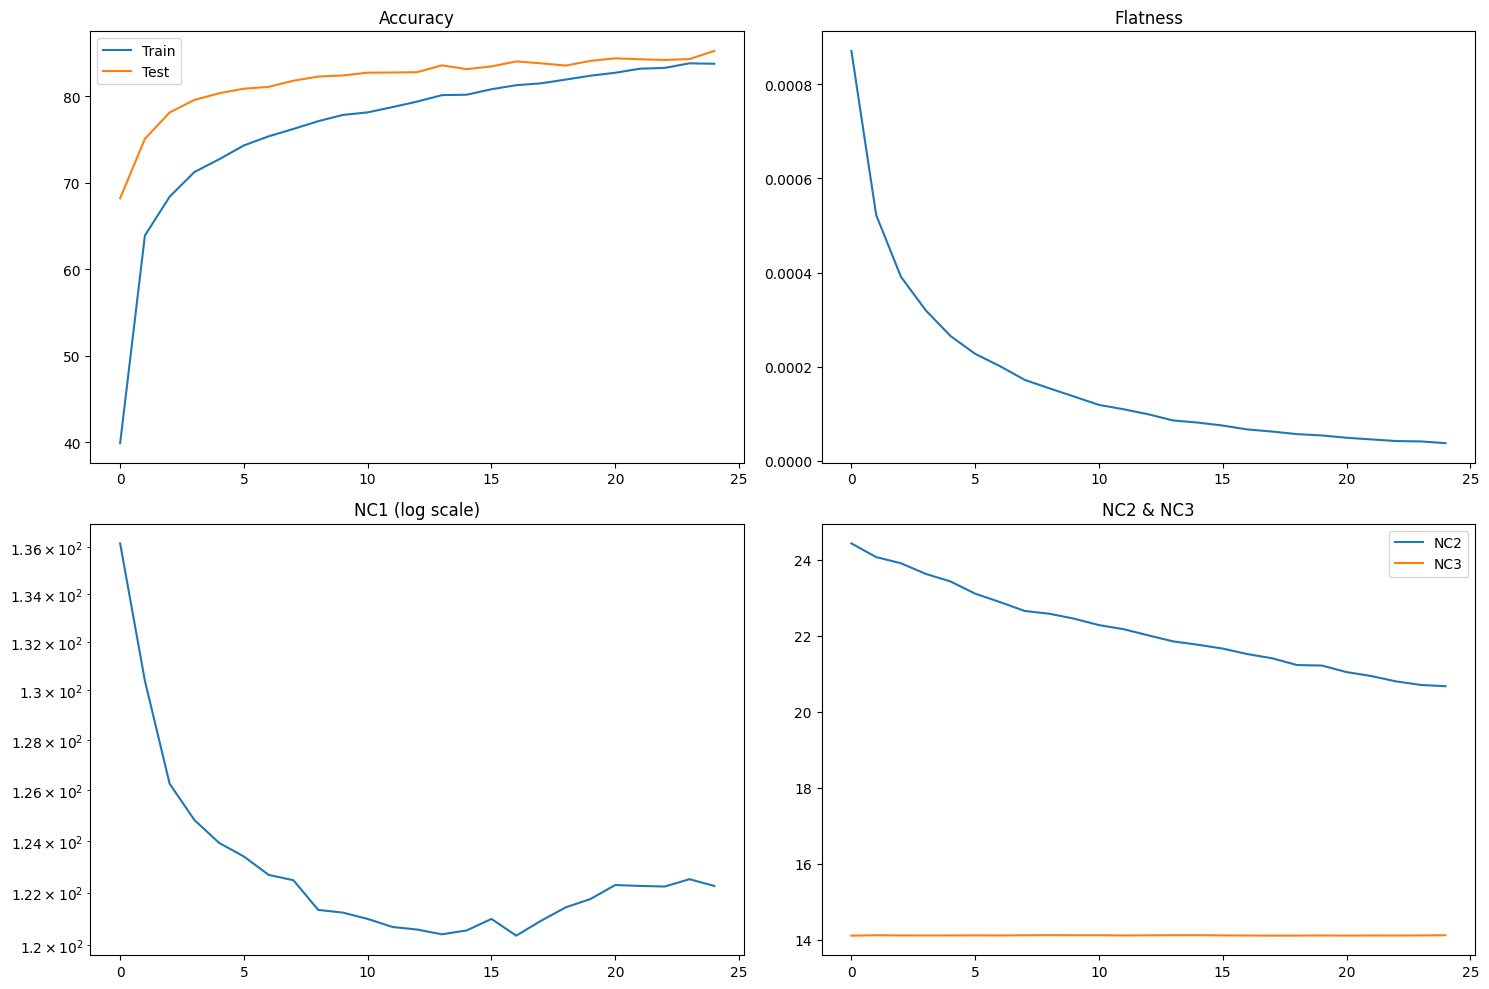

In [16]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.plot(train_acc_hist, label="Train")
plt.plot(test_acc_hist, label="Test")
plt.title("Accuracy")
plt.legend()

plt.subplot(2,2,2)
plt.plot(flatness_hist)
plt.title("Flatness")

plt.subplot(2,2,3)
plt.plot(nc1_hist)
plt.yscale('log')
plt.title("NC1 (log scale)")

plt.subplot(2,2,4)
plt.plot(nc2_hist, label="NC2")
plt.plot(nc3_hist, label="NC3")
plt.legend()
plt.title("NC2 & NC3")

plt.tight_layout()
plt.show()

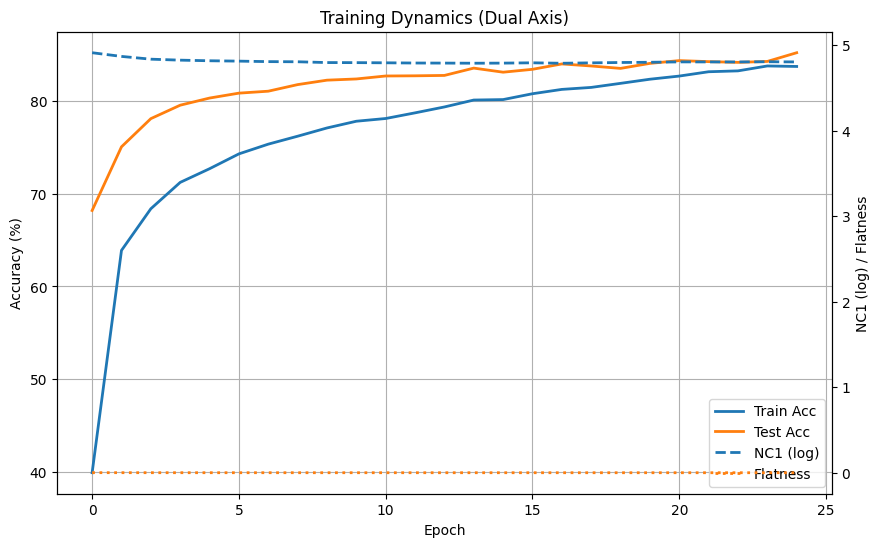

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# ---- LEFT AXIS (Accuracy) ----
ax1.plot(train_acc_hist, label="Train Acc", linewidth=2)
ax1.plot(test_acc_hist, label="Test Acc", linewidth=2)
ax1.set_ylabel("Accuracy (%)")
ax1.set_xlabel("Epoch")
ax1.grid(True)

# ---- RIGHT AXIS (NC1 + Flatness) ----
ax2 = ax1.twinx()

# Log scale for NC1 (important)
nc1_log = np.log(np.array(nc1_hist) + 1e-8)

ax2.plot(nc1_log, '--', label="NC1 (log)", linewidth=2)
ax2.plot(flatness_hist, ':', label="Flatness", linewidth=2)

ax2.set_ylabel("NC1 (log) / Flatness")

# ---- COMBINED LEGEND ----
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title("Training Dynamics (Dual Axis)")
plt.show()

Text(0.5, 1.0, 'nc2')

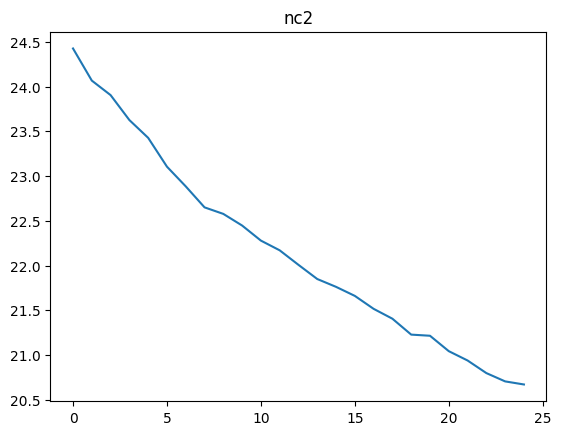

In [20]:
plt.plot(nc2_hist)
plt.title("nc2")

Text(0.5, 1.0, 'nc3')

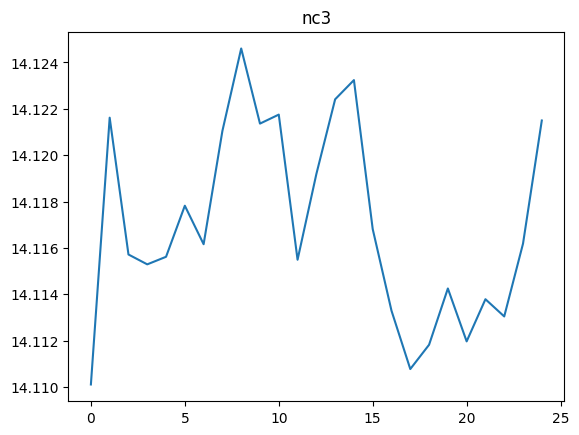

In [21]:
plt.plot(nc3_hist)
plt.title("nc3")